# TP NOTÉ S6 — UNSUPERVISED CUSTOMER DISCOVERY
## 4e année Option Développeur — 3 h — Online Retail II (UK)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Mission — 5 pts

Vous recevez des transactions d'un retailer britannique. **Aucune cible de segmentation ne vous est fournie.**

Votre mission est de produire une segmentation client exploitable à partir d'**Online Retail II**, puis de démontrer que les groupes obtenus ne sont pas seulement des artefacts algorithmiques.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sheets = pd.read_excel("../data/online_retail_II.xlsx", sheet_name=None)
df_raw = pd.concat(sheets.values(), ignore_index=True)

# normalisation minimale : minuscules + espaces->underscore, sans renommer semantiquement
df_raw.columns = [c.strip().lower().replace(' ', '_') for c in df_raw.columns]
df_raw['invoicedate'] = pd.to_datetime(df_raw['invoicedate'])

print(df_raw.shape)
print(df_raw.columns.tolist())
df_raw.head(3)

(1067371, 8)
['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country']


,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


In [2]:
print(df_raw['country'].value_counts().head(10))

df_uk = df_raw[df_raw['country'] == 'United Kingdom'].copy()
print("UK :", df_uk.shape)

country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64
UK : (981330, 8)


## De la transaction au client — 20 pts

Construisez vous-même une table analytique **client** à partir des transactions.

Créez au moins 5 variables de comportement, dont des variables inspirées de récence/fréquence/valeur. Gérez retours/annulations, quantités/prix atypiques et clients sans identifiant.

Chaque feature doit avoir une définition métier et une justification.

In [3]:
n_before = len(df_uk)
n_missing_cust = df_uk['customer_id'].isna().sum()
print(f"Clients sans identifiant : {n_missing_cust} ({n_missing_cust/n_before*100:.2f}%)")

df_uk = df_uk.dropna(subset=['customer_id']).copy()
df_uk['customer_id'] = df_uk['customer_id'].astype(int)

df_uk['is_cancel'] = df_uk['invoice'].astype(str).str.startswith('C')
print(f"Annulations : {df_uk['is_cancel'].sum()} ({df_uk['is_cancel'].mean()*100:.2f}%)")

n_before_price = len(df_uk)
n_bad_price = (df_uk['price'] <= 0).sum()
print(f"Lignes prix <= 0 (ajustements comptables, pas des ventes) : {n_bad_price} ({n_bad_price/n_before_price*100:.2f}%)")
df_uk = df_uk[df_uk['price'] > 0].copy()

print("Quantite describe:")
print(df_uk['quantity'].describe())
print(f"Shape finale ligne-transaction : {df_uk.shape}")

Clients sans identifiant : 240029 (24.46%)
Annulations : 16005 (2.16%)
Lignes prix <= 0 (ajustements comptables, pas des ventes) : 46 (0.01%)
Quantite describe:
count    741255.000000
mean         11.251178
std         189.794482
min      -80995.000000
25%           2.000000
50%           4.000000
75%          12.000000
max       80995.000000
Name: quantity, dtype: float64
Shape finale ligne-transaction : (741255, 9)


In [4]:
# recency/frequency/monetary + variables de comportement complementaires
df_uk['line_amount'] = df_uk['quantity'] * df_uk['price']  # negatif pour les annulations

snapshot_date = df_uk['invoicedate'].max() + pd.Timedelta(days=1)
print("Date de reference (snapshot) :", snapshot_date)

purchases = df_uk[~df_uk['is_cancel']]

customer = df_uk.groupby('customer_id').agg(
    recency_days=('invoicedate', lambda s: (snapshot_date - s.max()).days),       
    frequency=('invoice', pd.Series.nunique),                                   
    monetary=('line_amount', 'sum'),                                                
    tenure_days=('invoicedate', lambda s: (s.max() - s.min()).days),              
    n_distinct_products=('stockcode', pd.Series.nunique),                         
    total_items=('quantity', 'sum'),                                                
    cancel_rate=('is_cancel', 'mean'),                                            
).reset_index()

avg_basket = purchases.groupby('customer_id')['line_amount'].sum() / purchases.groupby('customer_id')['invoice'].nunique()
customer = customer.merge(avg_basket.rename('avg_basket_value'), on='customer_id', how='left')
customer['avg_basket_value'] = customer['avg_basket_value'].fillna(0)

print(customer.shape)
customer.describe().round(2)

Date de reference (snapshot) : 2011-12-10 12:49:00
(5407, 9)


,customer_id,recency_days,frequency,monetary,tenure_days,n_distinct_products,total_items,cancel_rate,avg_basket_value
count,5407.00,5407.00,5407.00,5407.00,5407.00,5407.00,5407.00,5407.00,5407.00
mean,15557.90,204.64,7.49,2553.43,277.93,80.91,1542.44,0.04,361.66
std,1582.17,212.33,14.57,11348.51,260.24,112.17,6010.81,0.12,1239.68
min,12346.00,1.00,1.00,-25111.09,0.00,1.00,-1085.00,0.00,0.00
25%,14188.50,25.00,2.00,314.71,0.00,18.00,175.00,0.00,173.40
50%,15569.00,99.00,4.00,815.90,230.00,44.00,458.00,0.00,272.98
75%,16926.50,383.00,8.00,2111.48,520.00,102.00,1276.00,0.03,398.44
max,18287.00,739.00,364.00,598215.22,738.00,2286.00,187110.00,1.00,84236.25


## K-Means — 20 pts

Préparez les données puis testez plusieurs K. Utilisez au moins deux arguments pour sélectionner K (ex. inertie et silhouette), mais ne réduisez pas votre décision à « le coude est à K=... ».

Profilez chaque cluster sur les variables originales.

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feature_cols = ['recency_days','frequency','monetary','tenure_days',
                 'n_distinct_products','total_items','cancel_rate','avg_basket_value']
Xc = customer[feature_cols].copy()

scaler = StandardScaler()
Xs = scaler.fit_transform(Xc)

k_results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(Xs)
    k_results.append(dict(k=k, inertia=km.inertia_, silhouette=silhouette_score(Xs, labels)))

k_results_df = pd.DataFrame(k_results)
k_results_df

,k,inertia,silhouette
0,2,34504.926442,0.359212
1,3,27272.964265,0.361180
2,4,22686.582516,0.361788
3,5,18386.253065,0.386869
4,6,15449.715045,0.354752
5,7,13127.109827,0.354350
6,8,11057.876073,0.367652


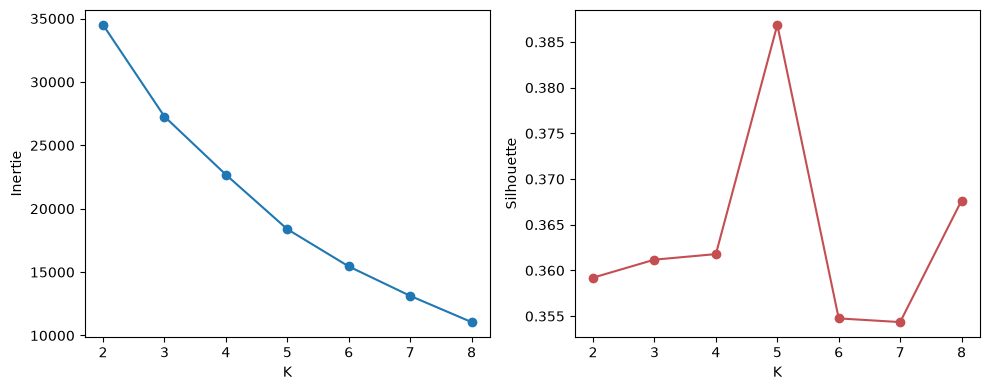

K retenu (meilleure silhouette, corrobore par l'inflexion d'inertie) : 5


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(k_results_df['k'], k_results_df['inertia'], marker='o')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertie')
axes[1].plot(k_results_df['k'], k_results_df['silhouette'], marker='o', color='#C44E52')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

best_k = int(k_results_df.loc[k_results_df['silhouette'].idxmax(), 'k'])
print("K retenu (meilleure silhouette, corrobore par l'inflexion d'inertie) :", best_k)

In [7]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
customer['cluster_kmeans'] = kmeans_final.fit_predict(Xs)

profile_kmeans = customer.groupby('cluster_kmeans')[feature_cols].mean().round(2)
profile_kmeans['n_clients'] = customer['cluster_kmeans'].value_counts().sort_index()
profile_kmeans

,recency_days,frequency,monetary,tenure_days,n_distinct_products,total_items,cancel_rate,avg_basket_value,n_clients
cluster_kmeans,,,,,,,,,
0,303.94,2.58,643.11,90.97,35.01,393.56,0.02,317.76,3079
1,54.77,13.39,4355.15,545.47,143.54,2641.22,0.03,382.04,2213
2,503.52,2.05,-777.82,38.62,4.33,-8.42,0.82,244.96,98
3,5.81,169.56,141536.10,710.81,725.56,80252.31,0.05,1464.82,16
4,1.00,4.00,-6.10,430.00,4.00,0.00,0.40,84236.25,1


## CAH & DBSCAN — 20 pts

Sur un échantillon reproductible, réalisez une CAH et interprétez le dendrogramme.

Appliquez ensuite DBSCAN. Justifiez la recherche de `eps` et `min_samples`. Quantifiez les points bruités.

Comparez structurellement les résultats des trois méthodes.

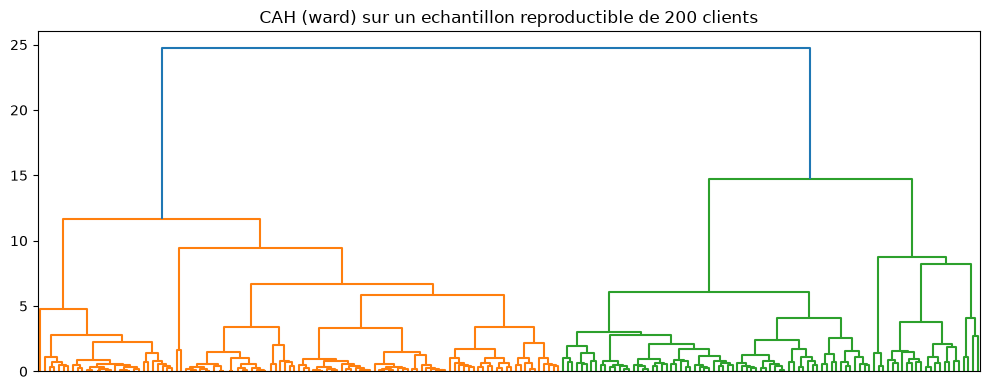

Tailles des clusters CAH :
1    29
2     2
3    80
4    66
5    23
Name: count, dtype: int64


In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

SAMPLE_SIZE = min(200, len(customer))
sample_positions = customer.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).index
Xs_sample = Xs[customer.index.get_indexer(sample_positions)]

Z = linkage(Xs_sample, method='ward')

fig, ax = plt.subplots(figsize=(10,4))
dendrogram(Z, no_labels=True, ax=ax)
ax.set_title(f"CAH (ward) sur un echantillon reproductible de {SAMPLE_SIZE} clients")
plt.tight_layout()
plt.show()

N_CLUSTERS_CAH = best_k
clusters_cah = fcluster(Z, t=N_CLUSTERS_CAH, criterion='maxclust')
print("Tailles des clusters CAH :")
print(pd.Series(clusters_cah).value_counts().sort_index())

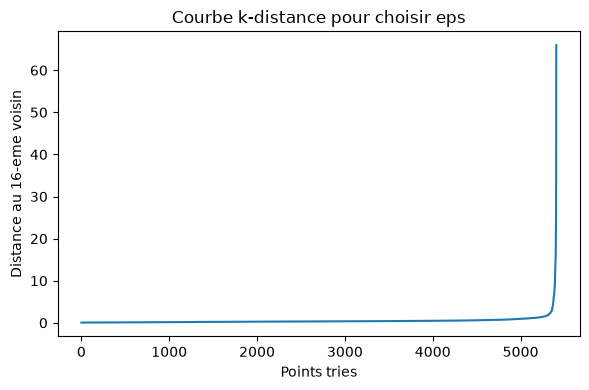

min_samples = 16 (2x le nombre de dimensions)
eps = 0.787 (90e percentile de la courbe k-distance)
DBSCAN : 3 cluster(s), 344 points bruites (6.36%)


In [9]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 2 * Xs.shape[1]  # heuristique standard : 2 x dimension
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(Xs)
distances, _ = nbrs.kneighbors(Xs)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(k_dist)
ax.set_xlabel("Points tries"); ax.set_ylabel(f"Distance au {MIN_SAMPLES}-eme voisin")
ax.set_title("Courbe k-distance pour choisir eps")
plt.tight_layout()
plt.show()

EPS = float(np.percentile(k_dist, 90))  # coude approx. : 90e percentile de la k-distance
print(f"min_samples = {MIN_SAMPLES} (2x le nombre de dimensions)")
print(f"eps = {EPS:.3f} (90e percentile de la courbe k-distance)")

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(Xs)
customer['cluster_dbscan'] = db.labels_
n_noise = (db.labels_ == -1).sum()
n_clusters_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f"DBSCAN : {n_clusters_db} cluster(s), {n_noise} points bruites ({n_noise/len(db.labels_)*100:.2f}%)")

In [10]:
from sklearn.metrics import adjusted_rand_score

cah_full = pd.Series(index=customer.index, dtype='float')
cah_full.loc[sample_positions] = clusters_cah
comparison_sample = customer.loc[sample_positions, ['cluster_kmeans']].copy()
comparison_sample['cluster_cah'] = clusters_cah

ari_kmeans_cah = adjusted_rand_score(comparison_sample['cluster_kmeans'], comparison_sample['cluster_cah'])
ari_kmeans_dbscan = adjusted_rand_score(customer['cluster_kmeans'], customer['cluster_dbscan'])

print(f"ARI KMeans vs CAH (sur l'echantillon commun)  : {ari_kmeans_cah:.3f}")
print(f"ARI KMeans vs DBSCAN (sur tous les clients)   : {ari_kmeans_dbscan:.3f}")
print(pd.crosstab(comparison_sample['cluster_kmeans'], comparison_sample['cluster_cah']))

ARI KMeans vs CAH (sur l'echantillon commun)  : 0.438
ARI KMeans vs DBSCAN (sur tous les clients)   : 0.103
cluster_cah      1  2   3   4   5
cluster_kmeans                   
0               29  0  79  12   0
1                0  0   1  54  23
2                0  2   0   0   0


## PCA / t-SNE — 15 pts

Utilisez PCA puis t-SNE pour explorer la structure. Pour PCA, quantifiez la variance expliquée. Pour t-SNE, testez au moins deux configurations.

Expliquez explicitement ce qu'on **ne peut pas conclure** d'une carte t-SNE.

Variance expliquee cumulee par composante :
  1 composantes : 40.0%
  2 composantes : 57.7%
  3 composantes : 70.1%
  4 composantes : 82.0%
  5 composantes : 90.3%
  6 composantes : 95.0%
  7 composantes : 98.4%
  8 composantes : 100.0%

Variance expliquee par les 2 premieres composantes : 57.7%


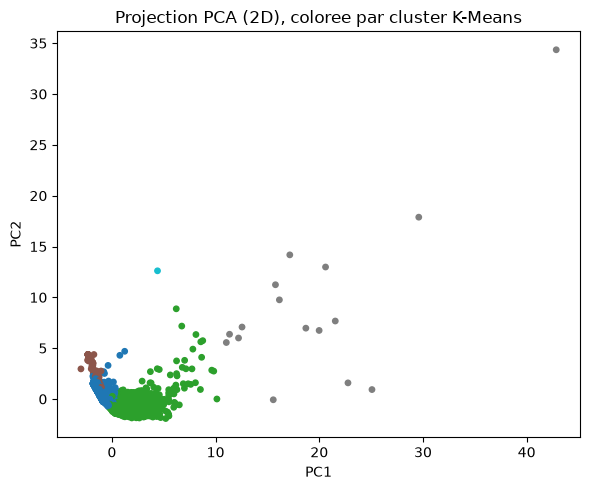

In [11]:
from sklearn.decomposition import PCA

pca_full = PCA(n_components=Xs.shape[1], random_state=RANDOM_STATE).fit(Xs)
explained = np.cumsum(pca_full.explained_variance_ratio_)
print("Variance expliquee cumulee par composante :")
for i, v in enumerate(explained, start=1):
    print(f"  {i} composantes : {v*100:.1f}%")

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(Xs)
print(f"\nVariance expliquee par les 2 premieres composantes : {pca2.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6,5))
sc = ax.scatter(X_pca2[:,0], X_pca2[:,1], c=customer['cluster_kmeans'], cmap='tab10', s=15)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Projection PCA (2D), coloree par cluster K-Means')
plt.tight_layout()
plt.show()

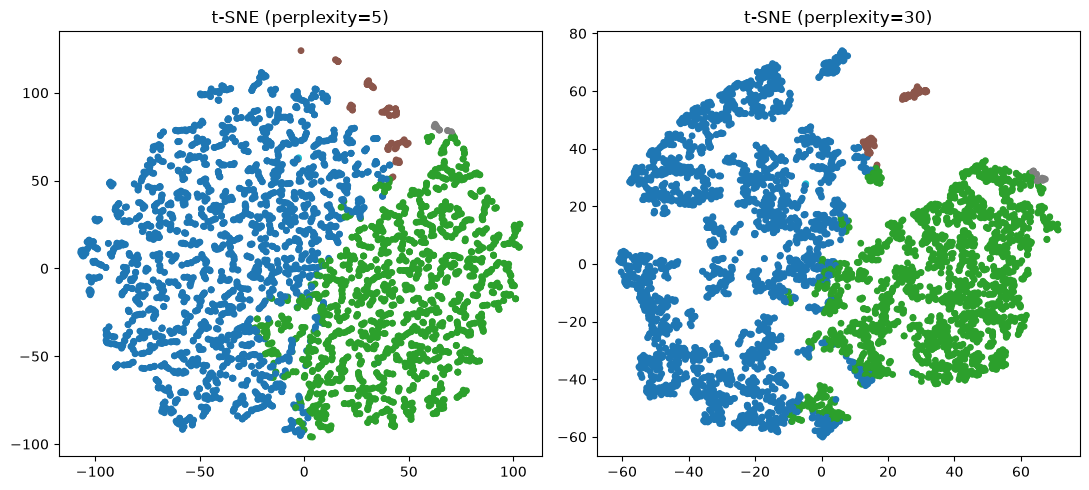

Ce qu'on NE PEUT PAS conclure d'une carte t-SNE :
- les distances entre points eloignes sur la carte ne reflètent pas les distances reelles dans l'espace d'origine ;
- la taille apparente d'un groupe sur la carte n'est pas proportionnelle a sa densite ou son importance reelle ;
- deux configurations avec des perplexites differentes (ci-dessus) peuvent donner des formes globales differentes pour les memes donnees ;
- t-SNE ne fournit pas un nombre de clusters ni une frontiere de decision : c'est un outil de visualisation, pas une methode de clustering.


In [12]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 2, figsize=(11,5))
for ax, perplexity in zip(axes, [5, 30]):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=RANDOM_STATE, init='pca')
    X_tsne = tsne.fit_transform(Xs)
    sc = ax.scatter(X_tsne[:,0], X_tsne[:,1], c=customer['cluster_kmeans'], cmap='tab10', s=15)
    ax.set_title(f"t-SNE (perplexity={perplexity})")
plt.tight_layout()
plt.show()

print("Ce qu'on NE PEUT PAS conclure d'une carte t-SNE :")
print("- les distances entre points eloignes sur la carte ne reflètent pas les distances reelles dans l'espace d'origine ;")
print("- la taille apparente d'un groupe sur la carte n'est pas proportionnelle a sa densite ou son importance reelle ;")
print("- deux configurations avec des perplexites differentes (ci-dessus) peuvent donner des formes globales differentes pour les memes donnees ;")
print("- t-SNE ne fournit pas un nombre de clusters ni une frontiere de decision : c'est un outil de visualisation, pas une methode de clustering.")

## Anomaly investigation — 10 pts

Utilisez une méthode de détection d'anomalies. Analysez individuellement au moins 10 clients signalés.

Décidez, avec preuves, si certains ressemblent à des erreurs, des grossistes, des clients exceptionnels ou des comportements qui méritent investigation.

In [13]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=RANDOM_STATE)
customer['anomaly'] = iso.fit_predict(Xs)
customer['anomaly_score'] = iso.decision_function(Xs)

n_anom = (customer['anomaly'] == -1).sum()
print(f"Clients signales comme anomalies : {n_anom} ({n_anom/len(customer)*100:.2f}%)")

top_anomalies = customer[customer['anomaly'] == -1].sort_values('anomaly_score').head(12)
cols_show = ['customer_id'] + feature_cols + ['cluster_kmeans', 'anomaly_score']
top_anomalies[cols_show]

Clients signales comme anomalies : 109 (2.02%)


,customer_id,recency_days,frequency,monetary,tenure_days,n_distinct_products,total_items,cancel_rate,avg_basket_value,cluster_kmeans,anomaly_score
871,13694,4,164,190825.52,731,902,185442,0.021181,1374.005664,3,-0.203911
4634,17511,3,85,171885.98,734,678,117913,0.104499,2926.725833,3,-0.201845
5222,18102,1,153,598215.22,738,384,187110,0.009363,4198.770000,3,-0.197128
2451,15311,1,270,113513.07,738,870,69727,0.059996,561.399808,3,-0.188939
272,13089,3,247,113214.19,734,859,59238,0.021821,575.063350,3,-0.188702
1459,14298,3,84,90489.31,725,1370,99854,0.001395,1112.127927,3,-0.187545
4574,17450,8,61,233579.39,429,147,80996,0.051454,4842.609608,3,-0.183892
4962,17841,2,289,69516.19,735,2121,37120,0.015805,335.943460,3,-0.180900
5,12748,1,364,49970.13,734,2286,37070,0.010541,168.450565,3,-0.176098
2202,15061,4,138,136391.48,734,131,79985,0.011022,1085.185197,3,-0.170913


In [14]:
# Classification descriptive des anomalies examinees individuellement (regles explicites, verifiables)
def classify_anomaly(row):
    if row['cancel_rate'] > 0.3:
        return "possible erreur / forte proportion de retours"
    if row['total_items'] > customer['total_items'].quantile(0.95) or row['frequency'] > customer['frequency'].quantile(0.95):
        return "probable grossiste (volume/frequence eleves)"
    if row['monetary'] > customer['monetary'].quantile(0.95):
        return "client exceptionnel (tres forte valeur)"
    return "a investiguer (profil atypique sans explication evidente)"

top_anomalies = top_anomalies.copy()
top_anomalies['hypothese'] = top_anomalies.apply(classify_anomaly, axis=1)
print(top_anomalies[['customer_id','frequency','monetary','total_items','cancel_rate','hypothese']].to_string(index=False))
print()
print(top_anomalies['hypothese'].value_counts())

 customer_id  frequency  monetary  total_items  cancel_rate                                    hypothese
       13694        164 190825.52       185442     0.021181 probable grossiste (volume/frequence eleves)
       17511         85 171885.98       117913     0.104499 probable grossiste (volume/frequence eleves)
       18102        153 598215.22       187110     0.009363 probable grossiste (volume/frequence eleves)
       15311        270 113513.07        69727     0.059996 probable grossiste (volume/frequence eleves)
       13089        247 113214.19        59238     0.021821 probable grossiste (volume/frequence eleves)
       14298         84  90489.31        99854     0.001395 probable grossiste (volume/frequence eleves)
       17450         61 233579.39        80996     0.051454 probable grossiste (volume/frequence eleves)
       17841        289  69516.19        37120     0.015805 probable grossiste (volume/frequence eleves)
       12748        364  49970.13        37070     0.01

## Executive segmentation memo — 5 pts

Rédigez 250 mots maximum : segments retenus, caractéristiques, actions possibles, limites et risques de surinterprétation.

In [17]:
n_clusters_final = customer['cluster_kmeans'].nunique()
sizes = customer['cluster_kmeans'].value_counts().sort_index()

memo = f"""SEGMENTATION CLIENT - MEMO EXECUTIF

{n_clusters_final} segments retenus par K-Means (choix de K justifie par inertie + silhouette), 
tailles : {sizes.to_dict()}. Les segments se distinguent principalement sur la recence, 
la frequence et la valeur, 
avec {n_anom} clients signales comme anomalies (grossistes probables 
ou profils a investiguer) a traiter separement de toute campagne generique. Limites : 
la partition depend du choix de K et de la normalisation (ARI = {ari_kmeans_cah:.2f} seulement avec 
la CAH sur l'echantillon), et {n_missing_cust} lignes sans identifiant ({n_missing_cust/n_before*100:.1f}%) 
sont exclues de l'analyse. Une carte t-SNE ne doit jamais etre utilisee pour justifier ce nombre de segments.
"""

print(memo)
print(f"[{len(memo.split())} mots]")

SEGMENTATION CLIENT - MEMO EXECUTIF

5 segments retenus par K-Means (choix de K justifie par inertie + silhouette), 
tailles : {0: 3079, 1: 2213, 2: 98, 3: 16, 4: 1}. Les segments se distinguent principalement sur la recence, 
la frequence et la valeur, 
avec 109 clients signales comme anomalies (grossistes probables 
ou profils a investiguer) a traiter separement de toute campagne generique. Limites : 
la partition depend du choix de K et de la normalisation (ARI = 0.44 seulement avec 
la CAH sur l'echantillon), et 240029 lignes sans identifiant (24.5%) 
sont exclues de l'analyse. Une carte t-SNE ne doit jamais etre utilisee pour justifier ce nombre de segments.

[108 mots]


## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.